# Farthest-Point Sampling and Voronoi Diagrams

We show standard and weighted FPS. In the weighted variant we invert the weight map so white regions attract more samples.


## Weighted FPS with white-prioritized sampling


In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.grid"] = True
rng = np.random.default_rng(0)

OUT = Path("python/farthest-point"); OUT.mkdir(parents=True, exist_ok=True)
n = 150
x = np.linspace(-1,1,n); y = np.linspace(-1,1,n)
X, Y = np.meshgrid(x,y)
img = 0.15 + 0.85*np.exp(-((X-0.4)**2+(Y+0.15)**2)/0.08) + 0.35*np.exp(-((X+0.3)**2+(Y-0.35)**2)/0.05)
img = np.clip(img, 0, 1)
pts = np.c_[X.ravel(), Y.ravel()]
w = img.ravel() + 1e-3  # more sampling where image is white

K = 170
chosen = [rng.integers(len(pts))]
d = np.full(len(pts), np.inf)
for _ in range(K-1):
    p = pts[chosen[-1]]
    d = np.minimum(d, np.sum((pts - p)**2, axis=1))
    score = w * d
    chosen.append(int(np.argmax(score)))
S = pts[chosen]


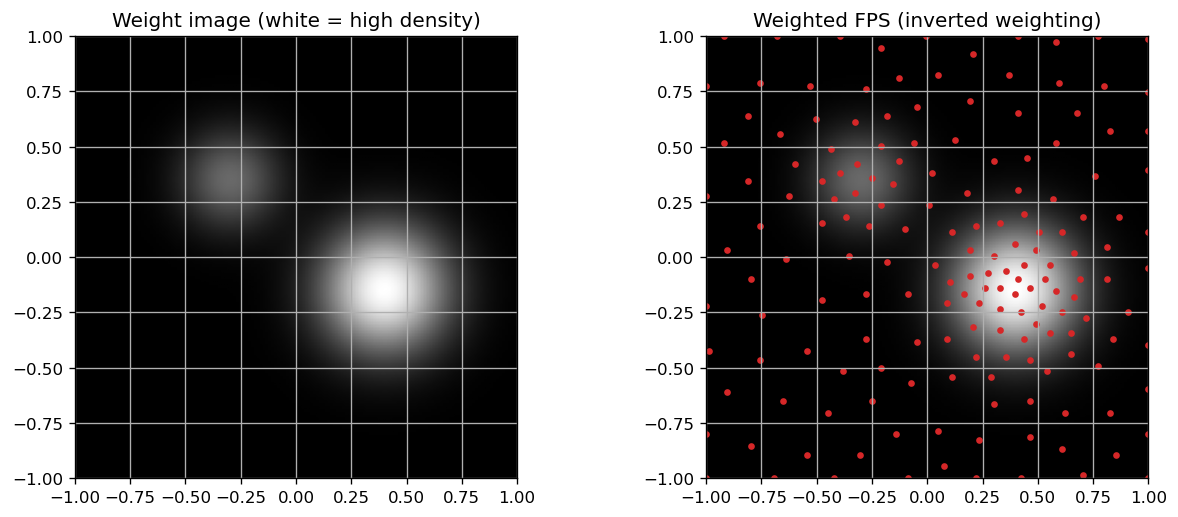

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.2), constrained_layout=True)
axes[0].imshow(img, origin="lower", extent=[-1,1,-1,1], cmap="gray")
axes[0].set_title("Weight image (white = high density)")
axes[1].imshow(img, origin="lower", extent=[-1,1,-1,1], cmap="gray")
axes[1].scatter(S[:,0], S[:,1], s=9, c="tab:red")
axes[1].set_title("Weighted FPS (inverted weighting)")
for ax in axes:
    ax.set_aspect("equal")
fig.savefig(OUT / "snippet.png", bbox_inches="tight")
plt.show()
